# Data profiling, cleaning and data story.

In [ ]:
!pip3 install seaborn

In [20]:
#Importing all the required modules for this notebook in this cell.
import pandas as pd
from IPython import display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
print("All modules imported!!")

All modules imported!!


In [7]:
df = sns.load_dataset('titanic')
df.to_csv("titanic.csv",index=False)
print(f"Dataframe before cleaning")
df.info()
df.describe()
df.shape
df.head()
missing_count = df.isnull().sum()
cols = df.columns
missing_percent = ((missing_count / len(df)) * 100).round(2)
missing_df = pd.DataFrame({
    'Column' : cols,
    'Total missing': missing_count,
    'Percentage' : missing_percent,
    })
missing_report = missing_df[missing_df['Total missing'] > 0].sort_values(by='Percentage',ascending = False)
if missing_report.empty: 
    print("Dataset does not contain any null values.")
else:
    print(missing_report)
drop_cols = missing_percent[missing_percent > 30].index.tolist()
impute_cols = missing_percent[(missing_percent >= 5) & (missing_percent <= 30)].index.tolist() 
drop_rows = missing_percent[(missing_percent > 0) & (missing_percent < 5)].index.tolist()
#Dropping columns whose missing values are greater than 50 percent. 
if drop_cols:
    print(f"Dropping column whose missing values are more than 30 percent: {drop_cols}")
    df = df.drop(columns = drop_cols)
for col in impute_cols:
    if col in df.columns:
        #imputing numeric values with median since median is robust to outliers.
        if pd.api.types.is_numeric_dtype(df[col]):
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"Imputing numeric column '{col}' with Median({median_val:.2f})'")
        #Imputing categorical values with mode
        else:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"Imputing categorical column {col} with mode ({mode_val})")
#Drop rows where missing values <5%
if drop_rows: 
    #filter only columns that still exist in the dataframe.filter
    valid_cols = [c for c in drop_rows if c in df.columns]
    print(f"Dropping rows with missing values in columns (<5% missing): {valid_cols}")
    df = df.dropna(subset=valid_cols)
print(f"Dataframe after cleaning")
df.info()
df.describe()
df.shape
df.head()

Dataframe before cleaning
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
                  Column  Total missing  Percentage
deck            

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


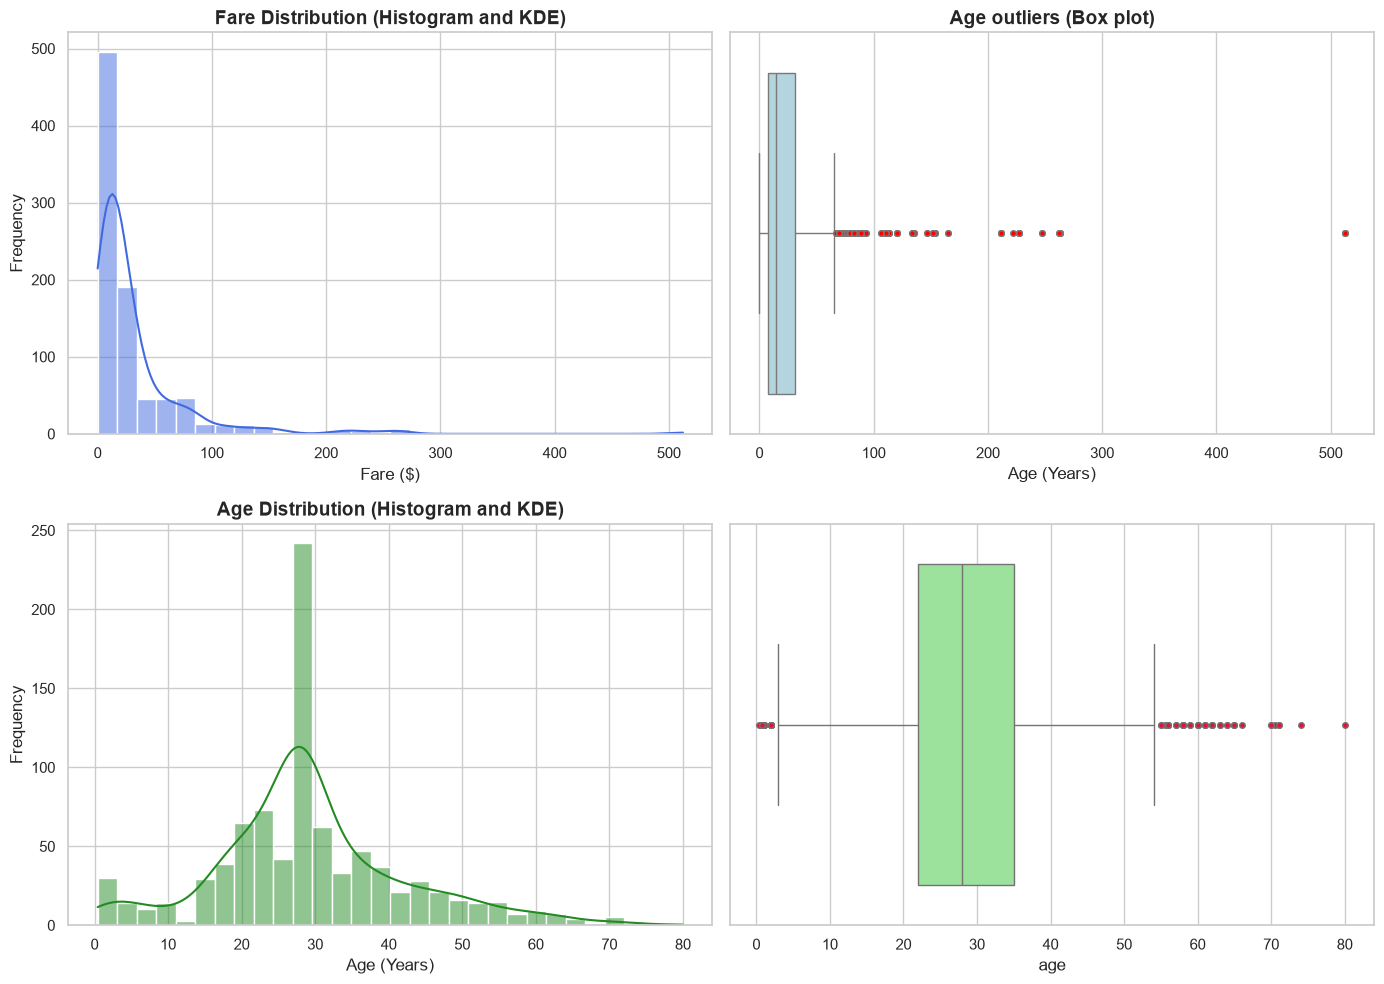

In [8]:
#Plotting histograms and box plots for fare and age
sns.set_theme(style='whitegrid')
fig,axes = plt.subplots(nrows=2, ncols=2, figsize=(14,10))
#-----------------Fare plots----------------------------------------
#Histogram (including KDE)
sns.histplot(df['fare'],kde=True,ax=axes[0,0],
            bins=30,color = 'royalblue')
axes[0,0].set_title('Fare Distribution (Histogram and KDE)',
            fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Fare ($)')
axes[0,0].set_ylabel('Frequency')
#Box plot
sns.boxplot(x = df['fare'], ax=axes[0,1], color = 'lightblue',
            flierprops = {'marker': "o", "markersize": 4, 'markerfacecolor':'red'})
axes[0,1].set_title('Fare outliers (Box plot)',fontsize=14,fontweight='bold')
axes[0,1].set_xlabel('Fare ($)')
#-----------------Age plots-----------------------------------------
#Histogram with KDE
sns.histplot(df['age'],kde=True,ax=axes[1,0],
            bins=30,color = 'forestgreen')
axes[1,0].set_title('Age Distribution (Histogram and KDE)',
            fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Age (Years)')
axes[1,0].set_ylabel('Frequency')
#Box plot
sns.boxplot(x = df['age'], ax=axes[1,1], color = 'lightgreen',
            flierprops = {'marker': "o", "markersize": 4,'markerfacecolor':'crimson'})
axes[0,1].set_title('Age outliers (Box plot)',fontsize=14,fontweight='bold')
axes[0,1].set_xlabel('Age (Years)')
plt.tight_layout()
plt.show()

In [9]:
def get_iqr_outliers(df: pd.DataFrame,columns: list) -> pd.DataFrame:
    outlier_summary = []
    for col in columns:
        series = df[col]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5*iqr
        upper_bound = q3 + 1.5*iqr
        is_outlier = (series < lower_bound) | (series > upper_bound)
        outlier_count = is_outlier.sum()
        outlier_percent = (outlier_count / len(series)) * 100
        outlier_summary.append({
            'column' : col,
            'Q1 (25%)' : round(q1,2),
            'Q3 (75&)' : round(q3,2),
            'IQR': round(iqr,2),
            'Lower Bound' : round(lower_bound, 2),
            'Upper Bound' : round(upper_bound,2),
            'Outlier Count': outlier_count,
            'Outlier (%)' : round(outlier_percent,2)
        })
    return pd.DataFrame(outlier_summary)
# Run get_iqr_outliers function for fare and age columns
target_cols = ['fare','age']
outliers_report = get_iqr_outliers(df,target_cols)
outliers_report

,column,Q1 (25%),Q3 (75&),IQR,Lower Bound,Upper Bound,Outlier Count,Outlier (%)
0,fare,7.9,31.0,23.1,-26.76,65.66,114,12.82
1,age,22.0,35.0,13.0,2.50,54.50,65,7.31


#### Based on the median, mean and mode values for the fare column, I can determine that the data in fare column is heavily right skewed, because median defines the middle value which is 14.45 dollars, when it comes to mode(where the peak of the fare is located) is 8.05 dollars, which tells us that most of the passengers bought cheap third class ticket for 8.05 dollars, however mean is at 32.1 this means that there are some high value customers who bought the tickets for first class tickets(more than 100$) which eventually pulled the mean away from median and mode to the right to 32.1 dollars making it heavily right skewed. 

In [10]:
median_values = df['fare'].median()
mean_values = df['fare'].mean()
mode_values = df['fare'].mode()[0]

print(round(median_values,2))
print(round(mean_values,2))
print(round(mode_values,2))

14.45
32.1
8.05


In [11]:
#Create masks for sex
mask_female = (df['sex'] == 'female')
mask_male = (df['sex'] == 'male')
#Survival rate for female
female_survival = df[mask_female]['survived'].mean()*100
#Survival rate for male
male_survival = df[mask_male]['survived'].mean()*100
print(f"---1. Survival rate by Sex------")
print(f"Female Survival rate: {female_survival:.2f}% (Total: {mask_female.sum()})")
print(f"Male survival rate: {male_survival:.2f}% (Total: {mask_male.sum()})")
#Individual class masks
mask_c1 = (df['pclass'] == 1)
mask_c2 = (df['pclass'] == 2)
mask_c3 = (df['pclass'] == 3)
mask_upper = (df['pclass'] ==1) | (df['pclass'] ==2)

print(f"\n ---2. Survival rate by Pclass -------------")
#Survival rate for pclass 1
print(f"1st class: {df[mask_c1]['survived'].mean()*100:.2f}%")
#Survival rate for pclass 2
print(f"2nd class: {df[mask_c2]['survived'].mean()*100:.2f}%")
#Survival rate for pclass 3
print(f"3rd class: {df[mask_c3]['survived'].mean()*100:.2f}%")
#Combined suvival rate for pclass 1 and 2
print(f"Upper class(1st or 2nd): {df[mask_upper]['survived'].mean()*100:.2f}%")

# Combined survival rates for sex and pclass
results = []
for sex in ['female', 'male']:
    for pclass in [1,2,3]:
        #Boolean mask combining sex and pclass
        mask = (df['sex'] == sex ) & (df['pclass'] == pclass)
        subset = df[mask]
        total_passengers = len(subset)
        survivors = subset['survived'].sum()
        survival_rate = (survivors / total_passengers) * 100 if total_passengers > 0 else 0
        results.append({
            'Sex' : sex.capitalize(),
            'Pclass' : f"Class {pclass}",
            'Total Passengers' : total_passengers,
            'Survivors' : survivors,
            'Survival Rate (%)' : round(survival_rate,2)
        })
summary_df = pd.DataFrame(results)
summary_df

---1. Survival rate by Sex------
Female Survival rate: 74.04% (Total: 312)
Male survival rate: 18.89% (Total: 577)

 ---2. Survival rate by Pclass -------------
1st class: 62.62%
2nd class: 47.28%
3rd class: 24.24%
Upper class(1st or 2nd): 55.53%


,Sex,Pclass,Total Passengers,Survivors,Survival Rate (%)
0,Female,Class 1,92,89,96.74
1,Female,Class 2,76,70,92.11
2,Female,Class 3,144,72,50.00
3,Male,Class 1,122,45,36.89
4,Male,Class 2,108,17,15.74
5,Male,Class 3,347,47,13.54


------- 6*6 correlation matrix--------------


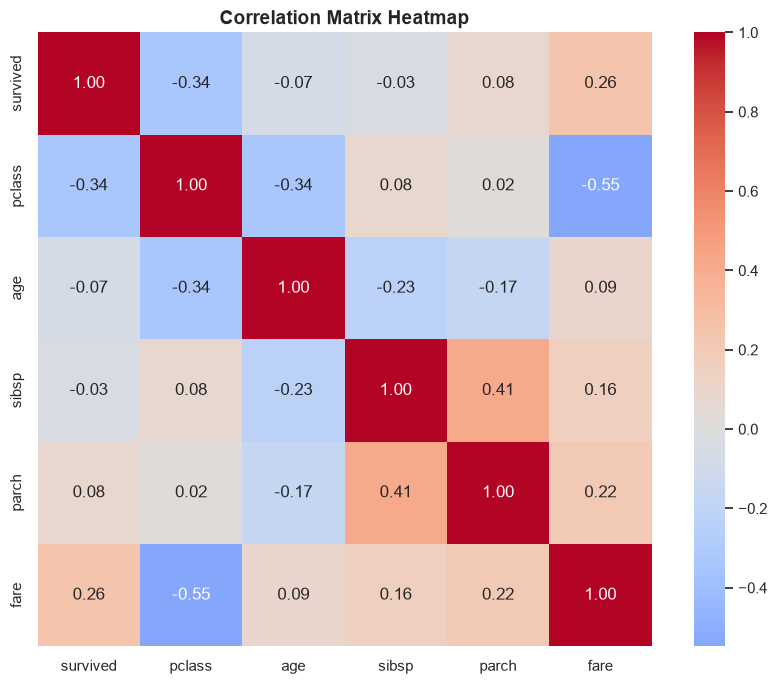

In [12]:
#Computing a correlation matrix for survived, pclass, age, sibsp, parch and fare
df_corr = df[['survived','pclass','age','sibsp','parch','fare']]
corr_matrix = df_corr.corr()
print(f"------- 6*6 correlation matrix--------------")
corr_matrix.round(2)
# -------------------------------------------------------------
# 3. Plot with sns.heatmap
# -------------------------------------------------------------
plt.figure(figsize=(9,7))
sns.heatmap(
    corr_matrix, 
    annot=True, # display values inside cells
    fmt= '.2f', #format upto 2 decimal places
    cmap = "coolwarm", 
    center = 0, 
    square = True,
    linecolor = "black"
)
plt.title("Correlation Matrix Heatmap", fontsize = 14, 
           fontweight="bold")
plt.tight_layout()
plt.show()

In [13]:
# 2. Extract unique off-diagonal pairs
target_cols = ['survived', 'pclass', 'age','sibsp','parch', 'fare']
pairs_list = []
for i in range(len(target_cols)):
    for j in range(i + 1, len(target_cols)):
        col1 = target_cols[i]
        col2 = target_cols[j]
        corr_val = corr_matrix.loc[col1, col2]
        
        pairs_list.append({
            'Feature 1': col1,
            'Feature 2': col2,
            'Correlation': round(corr_val, 4),
            'Abs_Correlation': round(abs(corr_val), 4)
        })
# 3. Convert to DataFrame and sort by absolute correlation descending
ranked_pairs = pd.DataFrame(pairs_list).sort_values(
    by='Abs_Correlation', ascending=False
).reset_index(drop=True)
# 4. Top 2 pairs
top_2 = ranked_pairs.head(2)
print("--- Top 2 Feature Pairs with Highest Absolute Correlation ---")
top_2

--- Top 2 Feature Pairs with Highest Absolute Correlation ---


,Feature 1,Feature 2,Correlation,Abs_Correlation
0,pclass,fare,-0.5482,0.5482
1,sibsp,parch,0.4145,0.4145


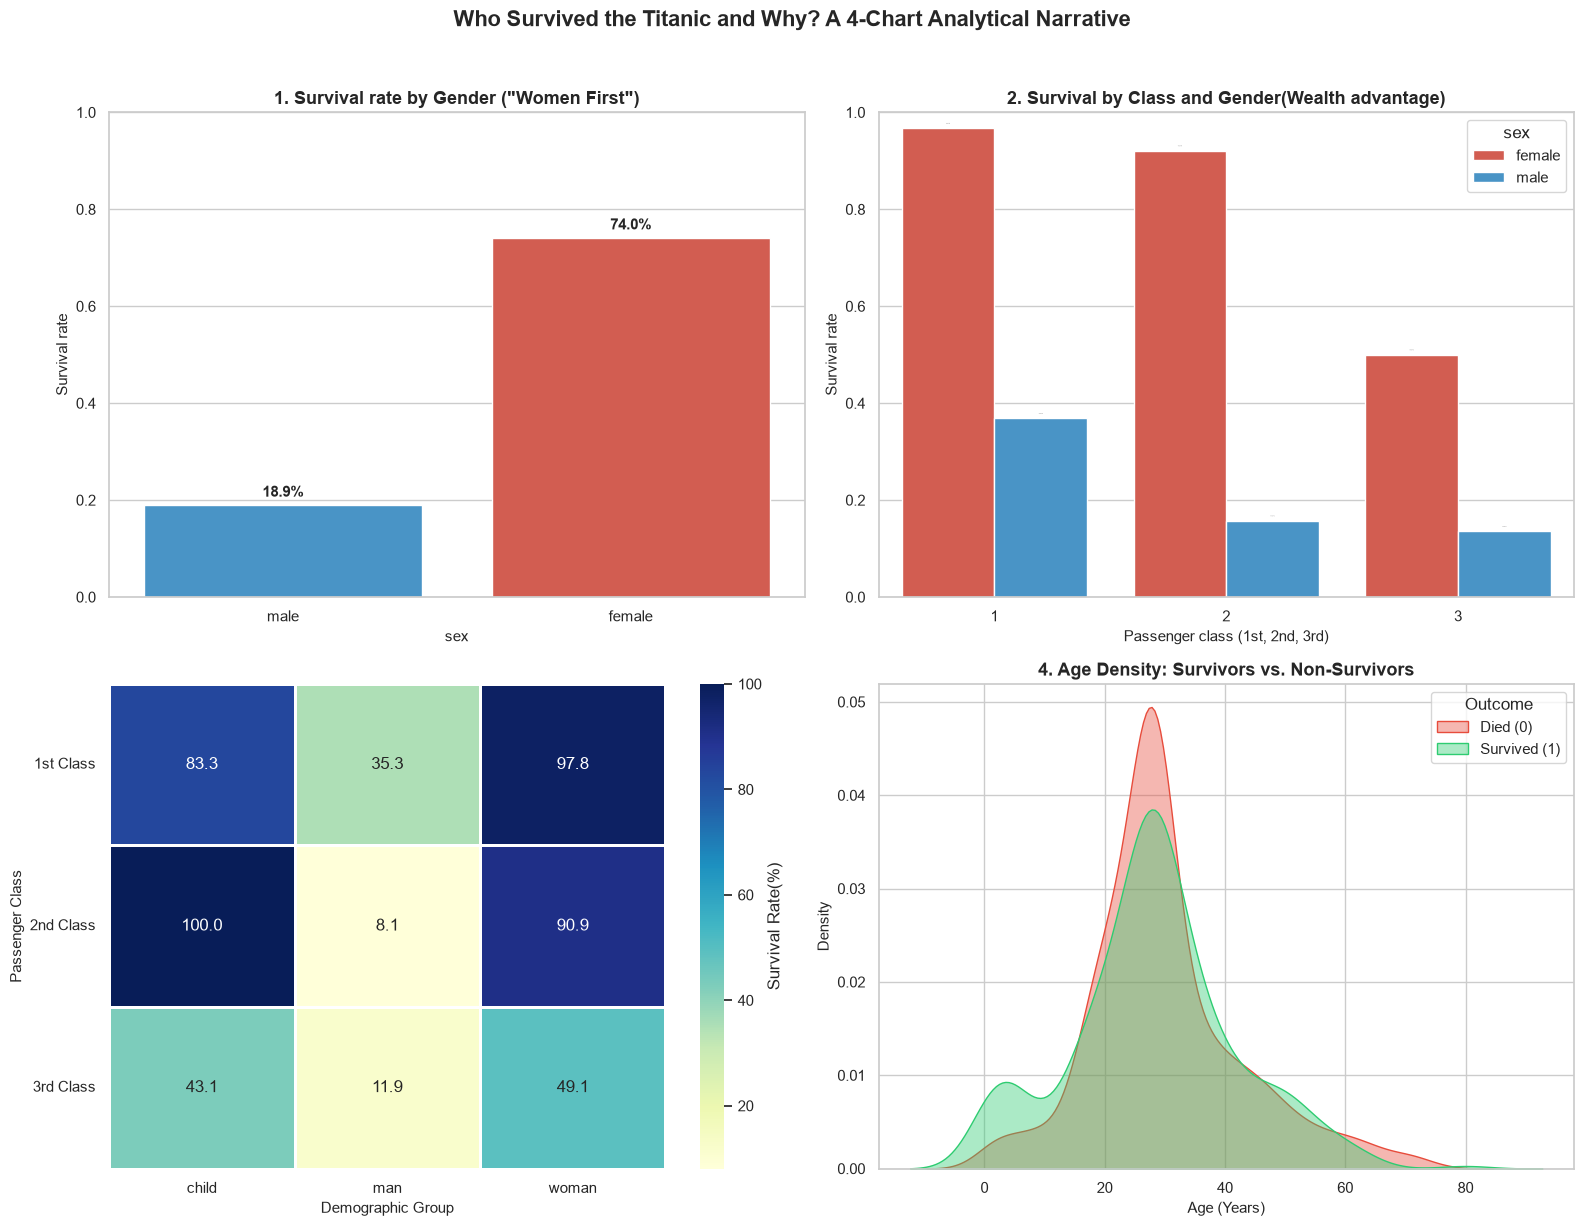

In [19]:
sns.set_theme(style='whitegrid',palette='muted')
fig,axes = plt.subplots(nrows=2,ncols=2,figsize=(16,12))
#Chart 1: Survival by sex(bar plot)
sns.barplot(data=df,x='sex',y='survived',
            palette={'female':'#e74c3c','male':'#3498db'},
            hue='sex',
            errorbar=None, ax=axes[0,0])
axes[0,0].set_title('1. Survival rate by Gender ("Women First")',
                    fontsize=13,fontweight='bold')
axes[0,0].set_xlabel('sex',fontsize=11)
axes[0,0].set_ylabel('Survival rate',fontsize=11)
axes[0,0].set_ylim(0,1.0)
#Below piece of code is to display survival percentages on top of the bars.
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{p.get_height()*100:.1f}%', (p.get_x()+p.get_width()/2., p.get_height()),
                        ha = 'center', va='bottom',fontsize=11,fontweight='bold',xytext=(0,4), textcoords='offset points')
#Chart 2: Survival by Class and Gender(Grouped by plot)
sns.barplot(data=df,x='pclass',y='survived',hue='sex',palette={'female':'#e74c3c','male':'#3498db'},errorbar=None,ax=axes[0,1])
axes[0,1].set_title('2. Survival by Class and Gender(Wealth advantage)',fontsize=13,fontweight='bold')
axes[0,1].set_xlabel('Passenger class (1st, 2nd, 3rd)', fontsize=11)
axes[0,1].set_ylabel('Survival rate', fontsize=11)
axes[0,1].set_ylim(0,1.0)
axes[0,1].legend(title='sex',loc='upper right')
for p in axes[0,1].patches:
    h=p.get_height()
    if h>0:
        axes[0,1].annotate(f'{h*100:.1f}%',(p.get_x() + p.get_width()/2., h),
                            ha='center',va='bottom',fontsize=0,fontweight='bold',
                            xytext=(0,3), textcoords='offset points')
#Chart 3: Heatmap (Survival rate by Class and Demographic)
survival_pivot = df.pivot_table(index='pclass',columns='who',values='survived',aggfunc='mean')*100
sns.heatmap(survival_pivot,annot=True,fmt='.1f',cmap='YlGnBu',cbar_kws={'label':'Survival Rate(%)'},linewidths=1,linecolor='white',ax=axes[1,0])
axes[1,0].set_xlabel('Demographic Group',fontsize=11)
axes[1,0].set_ylabel('Passenger Class',fontsize=11)
axes[1,0].set_yticklabels(['1st Class','2nd Class','3rd Class'],rotation=0)

# ------------------------------------------------------------------
# Chart 4 (Alternative 2): Age Distribution of Survivors vs. Non-Survivors
# ------------------------------------------------------------------
sns.kdeplot(data=df[df['survived'] == 0]['age'], label='Died (0)', color='#e74c3c', fill=True, alpha=0.4, ax=axes[1, 1])
sns.kdeplot(data=df[df['survived'] == 1]['age'], label='Survived (1)', color='#2ecc71', fill=True, alpha=0.4, ax=axes[1, 1])
axes[1, 1].set_title('4. Age Density: Survivors vs. Non-Survivors', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Age (Years)', fontsize=11)
axes[1, 1].set_ylabel('Density', fontsize=11)
axes[1, 1].legend(title='Outcome', loc='upper right')


plt.suptitle('Who Survived the Titanic and Why? A 4-Chart Analytical Narrative', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



# Who Survived the Titanic and Why?

---

## 1. Survival Rate by Gender ("Women First") - first chart

* Females had a **74.0%** survival rate compared to only **18.9%** for males.
*  Over **81%** of all male passengers perished in the disaster, representing the overwhelming majority of casualties.
* Gender exhibits the strongest direct separation in survival probability among all single variables plotted.
* Being female was the single most statistically favorable condition for survival across the entire dataset.

---

## 2. Survival by Class and Gender (Wealth Advantage) - Second chart

* Higher ticket classes directly translated to higher survival rates for both women and men.
* 1st Class and 2nd Class females experienced near-total survival (~**96.8%** and ~**92.1%**), whereas 3rd Class female survival dropped to **50.0%**.
* 1st Class men were almost three times more likely to survive (~**36.9%**) compared to 3rd Class men (~**13.5%**).
* Survival rates for both males and females decrease progressively as passenger class moves from **1st --> 2nd --> 3rd Class**
* Even females in 3rd Class had lower survival (**50.0%**) than the average survival rate of all upper-class groups combined.

---

## 3. Survival Rate (%) Heatmap (Class vs. Demographic) - Third Chart

* **Children in Upper Classes Fully Protected:** 2nd Class children had a **100.0%** survival rate, and 1st Class children had **83.3%**.
* In 3rd Class, children survived at **43.1%**, women at **49.1%**, and men at **11.9%**, showing reduced survival across all age/gender brackets compared to 1st and 2nd Class.
* 2nd Class men experienced the lowest overall survival rate at **8.1%**, followed closely by 3rd Class men at **11.9%**.
* 2nd Class children (**100.0%**), 1st Class women (**97.8%**), 2nd Class women (**90.9%**), and 1st Class children (**83.3%**) recorded the highest survival rates across all groups.

---

## 4. Age Density: Survivors vs. Non-Survivors

* The green survivor density curve exceeds the red non-survivor curve below age 10, showing that children had a higher probability of survival relative to their population size.
* The red density curve spikes heavily between ages **20 and 40**, representing the majority of working-age male passengers and crew who did not survive.
* Passengers over age **60** show higher relative density in the mortality curve due to limited physical mobility during rapid evacuation.
* Survivors exhibit a bimodal distribution with two distinct peaks: young children ($<10$ years) and young-to-middle-aged adult women ($20–35$ years).

---

## Conclusion

Based strictly on the empirical data visualized across all four charts:
* **Who Survived:**
  * **Females in 1st and 2nd Class** ($91\%–98\%$ survival).
  * **Children in 1st and 2nd Class** ($83\%–100\%$ survival).
  * **1st Class adult males** ($35.3\%$ survival vs. $<12\%$ for other adult men).
* **Who Did not survive:**
  * **Adult males in 2nd and 3rd Class** ($88\%–92\%$ mortality).
  * **3rd Class passengers across all demographics** (children and women experienced a $\approx 40–50\%$ drop in survival compared to upper classes).
  * **Elderly passengers** ($60+$ years).
* **The "Why":** Survival was statistically driven by a two-tier hierarchy: **Gender and Age (women and children prioritized over adult men)** acted as the primary filter, while **Passenger Class (socioeconomic status)** acted as the secondary multiplier that amplified survival odds within every demographic group.


In [27]:
#Mean and standard deviation before scaling
print("Age before scaling -> Mean:", df['age'].mean().round(4), "| Std:", df['age'].std().round(4))
print("Fare before scaling -> Mean:", df['fare'].mean().round(4), "| Std:", df['fare'].std().round(4))

Age before scaling -> Mean: 29.3152 | Std: 12.9849
Fare before scaling -> Mean: 32.0967 | Std: 49.6975


In [28]:
#Standardizing age and fare using StandardScaler
scaler = StandardScaler()
df[['age_scaled','fare_scaled']] = scaler.fit_transform(df[['age','fare']])
#Sanity check: Mean should be approximately zero and standard deviation should be approximately 1
print("Scaled Age -> Mean:", df['age_scaled'].mean().round(4), "| Std:", df['age_scaled'].std().round(4))
print("Scaled Fare -> Mean:", df['fare_scaled'].mean().round(4), "| Std:", df['fare_scaled'].std().round(4))

Scaled Age -> Mean: 0.0 | Std: 1.0006
Scaled Fare -> Mean: 0.0 | Std: 1.0006
